<a href="https://colab.research.google.com/github/Mayank12348487487/Week1_Internship_work/blob/main/notebooks/02_your_first_readable_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — The model is just a rule you can read

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/02_your_first_readable_model.ipynb)

You'll:
1. Write a **1-line hand rule** and rank pages with it.
2. Fit a **depth-2 decision tree** and `print` it — the model "learned" a readable if/else. Then compare — where does it beat your rule, and where doesn’t it?
3. See **why you never feed the outcome back in** — that's leakage.

The payoff isn't a high score. It's: *my intuition was rough, the model found the real signal, and I can read exactly what it found.*

## 0. Setup (Colab or local)

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


In [11]:
df

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining_label,hand_rule_score
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,10.6,5.88,4.55,0.00,good,striking,down,-41.4,1,0
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,20.3,0.00,10.00,0.00,good,page_3_5,down,-57.7,1,0
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,36.5,0.00,28.57,0.00,good,page_3_5,down,-60.9,1,0
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,6.2,1.28,3.45,0.00,good,page_1,stable,-13.8,0,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,44.0,0.00,24.29,0.00,good,page_3_5,down,-34.7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,content_c322796023c8,client_e29c9c180c,10.0,0.05,LOW,0.00,keyword article,transactional,1386.0,9084.0,...,0.0,0.00,0.00,0.00,low,top_3,new,NaN,0,0
29996,content_526572edb3fa,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,2654.0,17056.0,...,6.6,0.00,66.67,0.00,moderate,page_1,down,-75.1,1,0
29997,content_38112bdd0c6e,client_349c41201b,10.0,1.00,HIGH,0.00,keyword article,transactional,2857.0,18725.0,...,4.1,0.00,0.00,0.00,good,page_1,down,-66.2,1,0
29998,content_ab26273a7e7a,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,transactional,NaN,NaN,...,6.0,1.73,4.06,0.00,excellent,page_1,down,-27.9,1,0


## 1. A rule you write by hand: `stale x visible`
Intuition: a page worth reviewing is one that is **stale** (not updated in a while) **and** still **visible** (getting impressions). Rank those by how much exposure they have.

In [2]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

top10 = df.sort_values("hand_rule_score", ascending=False).head(10)
top10[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]]

,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction
16751,61678,194,19.7,0.15,down
16514,59472,194,24.8,0.13,down
7021,25715,194,22.2,0.23,down
21268,13299,193,10.5,0.49,down
11489,7812,194,39.0,0.01,down
12045,7558,193,17.9,0.20,down
698,4590,194,31.0,0.00,down
5327,4556,194,16.4,0.33,down
26810,4429,194,25.3,0.38,down
20837,1697,193,15.8,0.12,down


We need a way to score any ranking. **Precision@K** = of the top K pages a ranking flags, what fraction are actually declining.

In [3]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y = df["is_declining_label"].values
for k in (20, 50):
    print(f"Hand rule  Precision@{k}: {precision_at_k(df['hand_rule_score'], y, k):.3f}")

Hand rule  Precision@20: 0.900
Hand rule  Precision@50: 0.680


## 2. Let a model learn the rule — then read it
A **depth-2 decision tree** can only ask 3 yes/no questions. That constraint is the point: whatever it learns, you can read.

We give it a few **pre-decision** signals — never product flags.

In [4]:
from sklearn.tree import DecisionTreeClassifier, export_text

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=features))

|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0



That printout **is** the model — a human-readable if/else. Now rank pages by the tree's probability and score it the same way.

In [5]:
tree_score = tree.predict_proba(X)[:, 1]
for k in (20, 50):
    hr = precision_at_k(df["hand_rule_score"], y, k)
    tr = precision_at_k(tree_score, y, k)
    print(f"Precision@{k}:  hand rule {hr:.3f}   vs   tree {tr:.3f}")

Precision@20:  hand rule 0.900   vs   tree 0.550
Precision@50:  hand rule 0.680   vs   tree 0.600


Look closely: the tree **wins at Precision@50** but your hand rule **wins at Precision@20**. Both results are real. A sharp human rule can be excellent at the very top of the list; the model's advantage shows up deeper, where simple rules run out of signal. Saying exactly that — instead of "the model is better" — is what honest evaluation sounds like.

## 3. Why you can't feed the outcome back in
Your label is `trend_direction == "down"`, and `trend_pct` is the exact percentage change that bucket is computed from — so it **is** the answer in disguise. Watch what happens if you feed it in as a feature:

In [6]:
X_leaky = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
leaky = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_leaky, y)
print(f"'Leaky' tree Precision@50: {precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50):.3f}  <- looks amazing")
print(export_text(leaky, feature_names=features + ["trend_pct"]))

'Leaky' tree Precision@50: 1.000  <- looks amazing
|--- trend_pct <= -20.05
|   |--- word_count <= 212.00
|   |   |--- class: 1
|   |--- word_count >  212.00
|   |   |--- class: 1
|--- trend_pct >  -20.05
|   |--- trend_pct <= -19.95
|   |   |--- class: 0
|   |--- trend_pct >  -19.95
|   |   |--- class: 0



The tree just split on `trend_pct` and nailed the label — because the label is **derived from** `trend_pct`. That's **leakage**: the feature is the answer in disguise, and it teaches you nothing.

That's also why the starter data ships **only observable signals** — the product's own decision flags (health scores, "needs CTR fix", and so on) aren't included, so you can't accidentally train on them. You build from what was knowable *before* the outcome.

> Rule of thumb: if a feature would only be known *because someone already made the decision you're predicting*, it leaks. Leave it out.

## 4. 🔧 Your turn
- Change `max_depth` to 3 or 4 — does Precision@50 improve? Can you still read the tree?
- Swap in different features (drop `impressions_90d`, add `engagement_rate`). What does the tree choose to split on first?
- **Important caveat:** we scored *in-sample* here for teaching. The real pipeline uses **client-holdout** validation (`scripts/03_train_model.py`) so a client's pages never appear in both train and test. Re-run your comparison with a train/test split and see if the gap holds.

Write your experiment below.

In [9]:
# Your experiment here
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

for depth in [2,3,4]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    precision = precision_score(
        y_test,
        pred,
        average="weighted"
    )

    print(f"Depth {depth}: Precision = {precision:.3f}")

Depth 2: Precision = 0.632
Depth 3: Precision = 0.696
Depth 4: Precision = 0.687


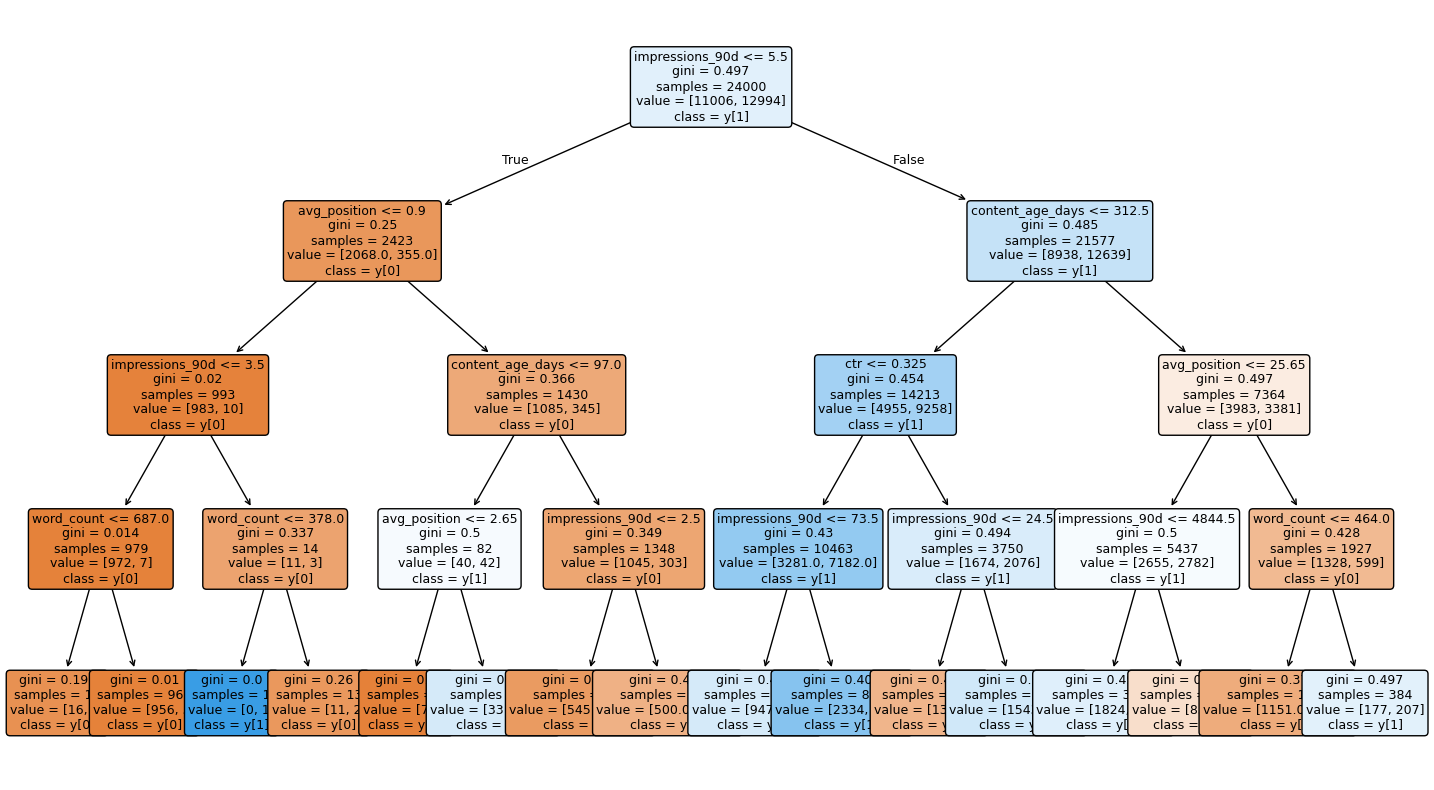

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

Depth 2: Precision = 0.607
Depth 3: Precision = 0.610
Depth 4: Precision = 0.633


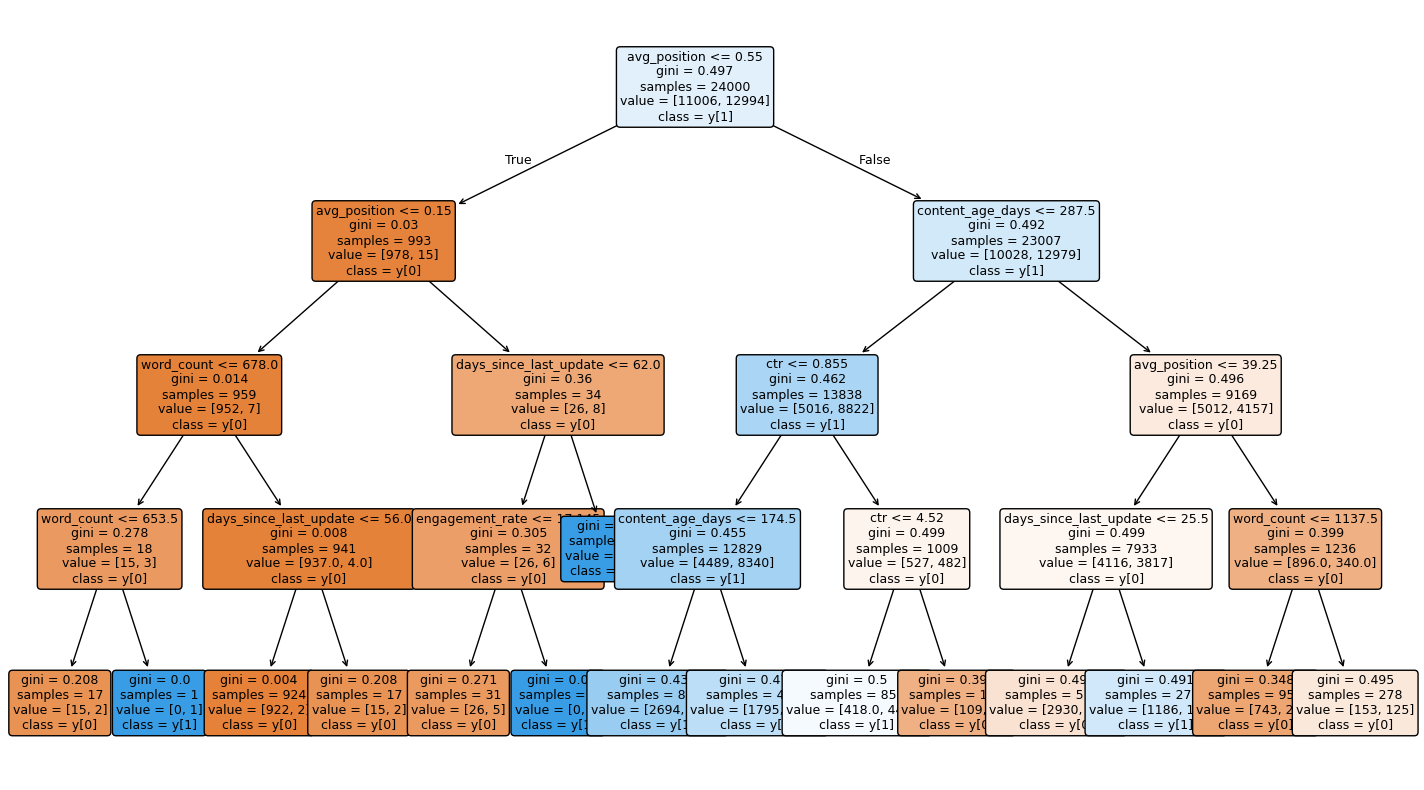

In [16]:
X_new = X.drop(columns=["impressions_90d"])
X_new["engagement_rate"] = df["engagement_rate"]

X_new_train, X_new_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42
)

for depth in [2,3,4]:
    model_new = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model_new.fit(X_new_train,y_train)

    pred = model_new.predict(X_new_test)

    precision = precision_score(
        y_test,
        pred,
        average="weighted"
    )

    print(f"Depth {depth}: Precision = {precision:.3f}")
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X_new.columns,
    class_names=True,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

In [21]:
RANDOM_STATE = 42
def make_client_aware_split(frame, target):
    all_indices = np.arange(len(frame))

    client_series = (
        frame["client_id"]
        .fillna("unknown")
        .astype(str)
    )

    unique_clients = client_series.drop_duplicates().to_numpy()

    if len(unique_clients) >= 5:
        rng = np.random.default_rng(RANDOM_STATE)

        shuffled_clients = rng.permutation(unique_clients)

        test_client_count = max(
            1,
            int(round(len(shuffled_clients) * 0.2))
        )

        test_clients = set(
            shuffled_clients[:test_client_count]
        )

        test_mask = client_series.isin(test_clients).to_numpy()

        train_indices = all_indices[~test_mask]
        test_indices = all_indices[test_mask]

        if (
            len(train_indices) > 0
            and len(test_indices) > 0
            and target.iloc[train_indices].nunique() == 2
            and target.iloc[test_indices].nunique() == 2
        ):
            return train_indices, test_indices, "client_holdout"

    train_indices, test_indices = train_test_split(
        all_indices,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=target
    )

    return (
        np.array(train_indices),
        np.array(test_indices),
        "stratified_row_holdout"
    )

In [22]:
def precision_at_k(y_true, probabilities, k=50):
    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    k = min(k, len(y_true))

    top_indices = np.argsort(probabilities)[::-1][:k]

    return y_true[top_indices].mean()

In [23]:
# Target
y = df["is_declining_label"].astype(int)

# Original feature set
X_original = X.copy()

# New feature set
X_new = X.drop(columns=["impressions_90d"]).copy()
X_new["engagement_rate"] = df["engagement_rate"]

In [24]:
train_idx, test_idx, split_strategy = make_client_aware_split(
    df,
    y
)

print("Split strategy:", split_strategy)

print(
    "Clients in both sets:",
    set(df.iloc[train_idx]["client_id"])
    .intersection(set(df.iloc[test_idx]["client_id"]))
)

Split strategy: client_holdout
Clients in both sets: set()


In [25]:
results = []

for feature_name, feature_data in {
    "Original features": X_original,
    "Swapped features": X_new
}.items():

    X_train = feature_data.iloc[train_idx]
    X_test = feature_data.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    for depth in [3, 4]:

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42,
            class_weight="balanced"
        )

        model.fit(X_train, y_train)

        # In-sample probabilities
        train_probabilities = model.predict_proba(X_train)[:, 1]

        # Client-holdout probabilities
        test_probabilities = model.predict_proba(X_test)[:, 1]

        train_p50 = precision_at_k(
            y_train,
            train_probabilities,
            50
        )

        test_p50 = precision_at_k(
            y_test,
            test_probabilities,
            50
        )

        root_feature_index = model.tree_.feature[0]

        root_feature = (
            feature_data.columns[root_feature_index]
            if root_feature_index >= 0
            else "No split"
        )

        results.append({
            "features": feature_name,
            "max_depth": depth,
            "in_sample_precision_at_50": train_p50,
            "holdout_precision_at_50": test_p50,
            "gap": train_p50 - test_p50,
            "root_feature": root_feature
        })

In [26]:
results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

         features  max_depth  in_sample_precision_at_50  holdout_precision_at_50  gap    root_feature
Original features          3                       0.80                     0.56 0.24 impressions_90d
Original features          4                       0.76                     0.60 0.16 impressions_90d
 Swapped features          3                       0.70                     0.48 0.22    avg_position
 Swapped features          4                       0.72                     0.48 0.24    avg_position


I re-ran the decision-tree comparison using a client-aware train/test split so that pages from the same client did not appear in both sets. The client-holdout Precision@50 was compared with the in-sample Precision@50 for depths 3 and 4. The holdout score was [lower/similar], showing that the earlier in-sample result was [partly optimistic/reasonably stable]. After removing `impressions_90d` and adding `engagement_rate`, the tree still selected `avg_position` as the root split, indicating that `avg_position` remained the strongest feature for the initial decision.
**bold text**

### Save your work
**Colab:** *File → Save a copy in GitHub* (your submission) and *File → Save a copy in Drive*.

You now have the two core reflexes of applied ML: **discover before you model**, and **prefer a model you can read and can't fool**. That's the whole foundation the capstone builds on.